In [132]:
import pandas as pd 
import os
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import torch
from sklearn.metrics import mean_squared_error
from math import sqrt
import math
import gpytorch
from matplotlib import pyplot as plt
from torch.nn.functional import mse_loss
from sklearn.metrics import mean_absolute_error
import torch.nn as nn


In [133]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [134]:
#average muscle thickness 
mm = pd.read_excel('/Users/taliacho/Downloads/Ranger/Bryan-Ranger/body_comp/US_data_1.29.24.xlsx')
mm['BM'] = mm[['B1M', 'B2M', 'B3M']].mean(axis=1,skipna=True)
mm['BA'] = mm[['B1A', 'B2A', 'B3A']].mean(axis=1,skipna=True)
mm['AA'] = mm[['A1A', 'A2A', 'A3A']].mean(axis=1,skipna=True)
mm['AM'] = mm[['A1M', 'A2M', 'A3M']].mean(axis=1,skipna=True)
mm['QA'] = mm[['Q1A', 'Q2A', 'Q3A']].mean(axis=1,skipna=True)
mm['QM'] = mm[['Q1M', 'Q2M', 'Q3M']].mean(axis=1,skipna=True)

mm_avg = mm[['Study ID','BM','BA','AM','AA','QM','QA']]

In [135]:
hp = pd.read_excel('/Users/taliacho/Downloads/Ranger/Bryan-Ranger/body_comp/Data_11.5.23.xlsx')
hp_check = hp[['Study_ID','FM','FFM']]
hp_avg = hp[['FM','FFM']]

    Study ID        BM        BA        AM        AA        QM        QA  \
0    1111517  0.970000  0.233333  0.243333  0.220000  1.073333  0.216667   
1    2111617  0.980000  0.166667  0.320000  0.253333  1.140000  0.183333   
2    3120117  0.790000  0.140000  0.170000  0.126667  0.970000  0.146667   
3    4120117  0.753333  0.176667  0.160000  0.176667  1.106667  0.180000   
4    5120817  0.526667  0.113333  0.153333  0.100000       NaN       NaN   
..       ...       ...       ...       ...       ...       ...       ...   
60  61051619  0.903333  0.260000  0.283333  0.256667  1.120000  0.266667   
61  63053119  0.983333  0.196667  0.210000  0.293333  1.193333  0.330000   
62  65050619  0.950000  0.216667  0.326667  0.330000  0.793333  0.566667   
63  66061919  0.873333  0.203333  0.256667  0.323333  1.416667  0.376667   
64  67062119  0.703333  0.253333  0.250000  0.340000  1.266667  0.333333   

        FM     FFM  
0   0.1466  2.0565  
1   0.1653  1.9892  
2   0.0832  1.5766  
3  

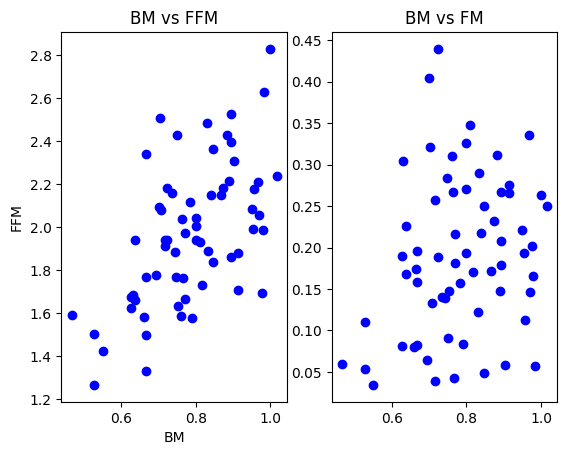

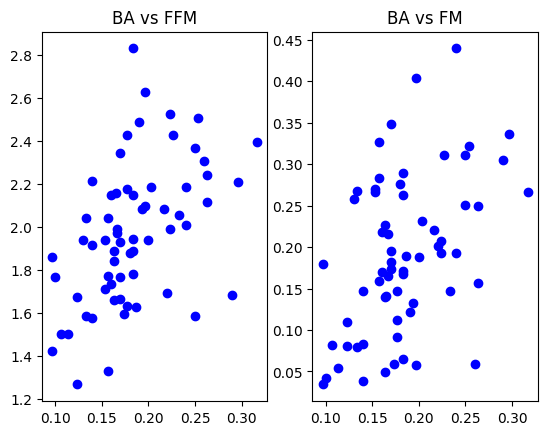

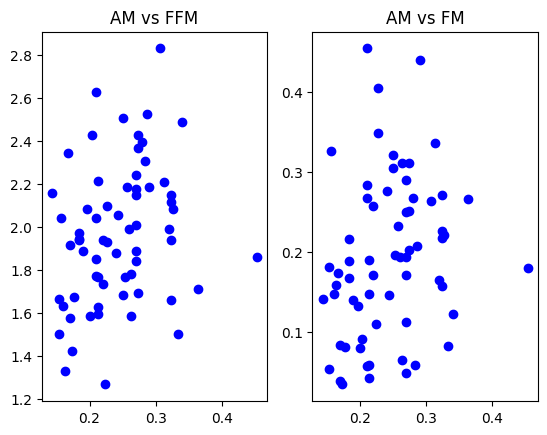

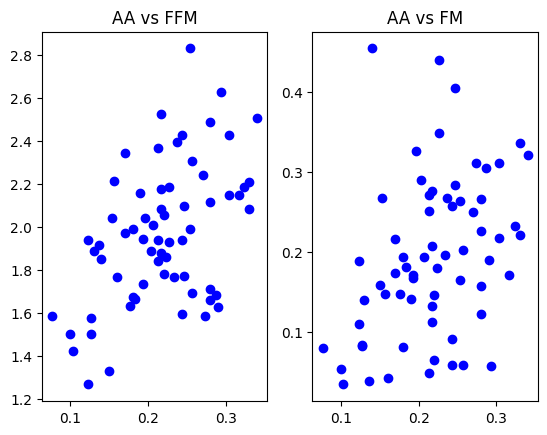

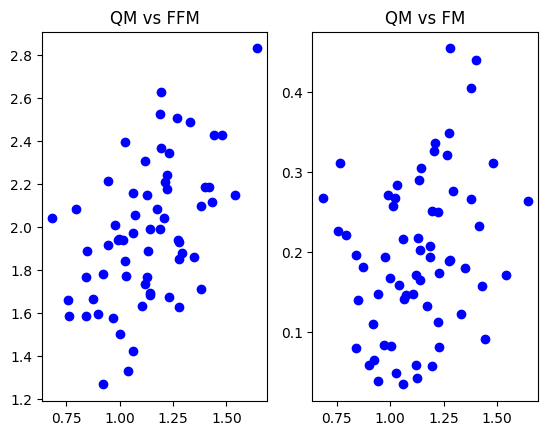

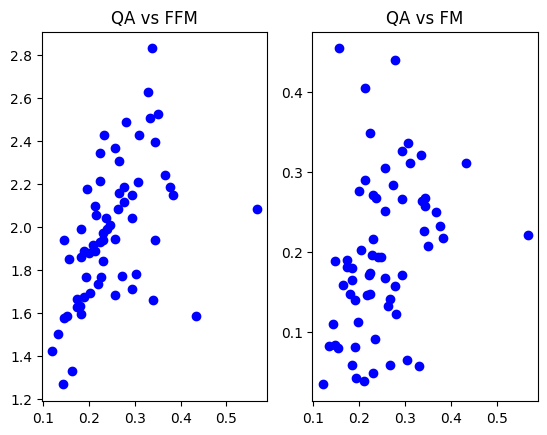

In [136]:
df = pd.concat([mm_avg, hp_avg], axis=1)
print(df)
plt.subplot(1, 2, 1)
plt.plot(df['BM'], df['FFM'], marker='o',linestyle= "",color='b')
plt.title('BM vs FFM')
plt.xlabel('BM')
plt.ylabel('FFM')
plt.subplot(1, 2, 2)
plt.plot(df['BM'], df['FM'], marker='o',linestyle= "",color='b')
plt.title('BM vs FM')
plt.show()

plt.subplot(1, 2, 1)
plt.plot(df['BA'], df['FFM'], marker='o',linestyle= "",color='b')
plt.title('BA vs FFM')
plt.subplot(1, 2, 2)
plt.plot(df['BA'], df['FM'], marker='o',linestyle= "",color='b')
plt.title('BA vs FM')
plt.show()

plt.subplot(1, 2, 1)
plt.plot(df['AM'], df['FFM'], marker='o',linestyle= "",color='b')
plt.title('AM vs FFM')
plt.subplot(1, 2, 2)
plt.plot(df['AM'], df['FM'], marker='o',linestyle= "",color='b')
plt.title('AM vs FM')
plt.show()

plt.subplot(1, 2, 1)
plt.plot(df['AA'], df['FFM'], marker='o',linestyle= "",color='b')
plt.title('AA vs FFM')
plt.subplot(1, 2, 2)
plt.plot(df['AA'], df['FM'], marker='o',linestyle= "",color='b')
plt.title('AA vs FM')
plt.show()

plt.subplot(1, 2, 1)
plt.plot(df['QM'], df['FFM'], marker='o',linestyle= "",color='b')
plt.title('QM vs FFM')
plt.subplot(1, 2, 2)
plt.plot(df['QM'], df['FM'], marker='o',linestyle= "",color='b')
plt.title('QM vs FM')
plt.show()

plt.subplot(1, 2, 1)
plt.plot(df['QA'], df['FFM'], marker='o',linestyle= "",color='b')
plt.title('QA vs FFM')
plt.subplot(1, 2, 2)
plt.plot(df['QA'], df['FM'], marker='o',linestyle= "",color='b')
plt.title('QA vs FM')
plt.show()

In [137]:
matrix_3d_df = np.zeros((len(df), 2, 12))
for matrix_index in range(12):  
    idx = 1 + matrix_index // 2  
    matrix_3d_df[:, 0, matrix_index] = df.iloc[:, idx].values
    if matrix_index % 2 == 0:
        matrix_3d_df[:, 1, matrix_index] = df.iloc[:, 7].values
    else:
        matrix_3d_df[:, 1, matrix_index] = df.iloc[:, 8].values

In [138]:
def split_data(data,train_size=0.8,test_size=0.1,random_state=None): #diff  outcomes for each run
    train,temp=train_test_split(data,train_size=train_size,random_state=random_state)
    test_and_valid_size = 1.0-train_size
    test_ratio = test_size/test_and_valid_size
    test,valid = train_test_split(temp,test_size=test_ratio,random_state=random_state)
    return train, test, valid

In [139]:
rmse = torch.zeros(12, 1)
mse = torch.zeros(12, 1)
mae = torch.zeros(12, 1)
mape = torch.zeros(12, 1)  

In [140]:
mse_loss = nn.MSELoss()
mae_loss = nn.L1Loss()

for index in range(12):
    train, test, valid = split_data(torch.tensor(matrix_3d_df[:, :, index], dtype=torch.float32))
    train = train[~torch.isnan(train).any(dim=1)]
    test = test[~torch.isnan(test).any(dim=1)]
    valid = valid[~torch.isnan(valid).any(dim=1)]

    train_x = train[:, 0]
    train_y = train[:, 1]
    test_x = test[:, 0]
    test_y = test[:, 1]

    # Define the model
    class ExactGPModel(gpytorch.models.ExactGP):
        def __init__(self, train_x, train_y, likelihood):
            super(ExactGPModel, self).__init__(train_x, train_y, likelihood)
            self.mean_module = gpytorch.means.ConstantMean()
            self.covar_module = gpytorch.kernels.ScaleKernel(gpytorch.kernels.RBFKernel())

        def forward(self, x):
            mean_x = self.mean_module(x)
            covar_x = self.covar_module(x)
            return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)

    # Initialize likelihood and model
    likelihood = gpytorch.likelihoods.GaussianLikelihood()
    model = ExactGPModel(train_x, train_y, likelihood)

    import os
    smoke_test = ('CI' in os.environ)
    training_iter = 2 if smoke_test else 50

    # Train the model
    model.train()
    likelihood.train()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.1)  # Includes GaussianLikelihood parameters
    mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, model)

    for i in range(training_iter):
        optimizer.zero_grad()
        output = model(train_x)
        loss = -mll(output, train_y)
        loss.backward()
        print('Iter %d/%d - Loss: %.3f   lengthscale: %.3f   noise: %.3f' % (
            i + 1, training_iter, loss.item(),
            model.covar_module.base_kernel.lengthscale.item(),
            model.likelihood.noise.item()
        ))
        optimizer.step()
    print("done with index ", index)

    # Evaluate the model
    model.eval()
    likelihood.eval()

    with torch.no_grad():
        preds = model(test_x)
        f_mean = preds.mean

        mse[index] = mse_loss(f_mean, test_y)
        rmse[index] = torch.sqrt(mse[index])
        mae[index] = mae_loss(f_mean, test_y)

        # Calculate MAPE
        mape[index] = torch.mean(torch.abs((f_mean - test_y) / test_y)) * 100  # MAPE formula

print("RMSE: ", rmse)
print("MSE: ", mse)
print("MAE: ", mae)
print("MAPE: ", mape)

Iter 1/50 - Loss: 0.790   lengthscale: 0.693   noise: 0.693
Iter 2/50 - Loss: 0.753   lengthscale: 0.744   noise: 0.644
Iter 3/50 - Loss: 0.715   lengthscale: 0.798   noise: 0.598
Iter 4/50 - Loss: 0.677   lengthscale: 0.854   noise: 0.554
Iter 5/50 - Loss: 0.638   lengthscale: 0.912   noise: 0.513
Iter 6/50 - Loss: 0.599   lengthscale: 0.971   noise: 0.474
Iter 7/50 - Loss: 0.559   lengthscale: 1.032   noise: 0.437
Iter 8/50 - Loss: 0.518   lengthscale: 1.094   noise: 0.403
Iter 9/50 - Loss: 0.477   lengthscale: 1.157   noise: 0.370
Iter 10/50 - Loss: 0.435   lengthscale: 1.221   noise: 0.340
Iter 11/50 - Loss: 0.393   lengthscale: 1.285   noise: 0.312
Iter 12/50 - Loss: 0.350   lengthscale: 1.349   noise: 0.286
Iter 13/50 - Loss: 0.307   lengthscale: 1.413   noise: 0.261
Iter 14/50 - Loss: 0.263   lengthscale: 1.476   noise: 0.239
Iter 15/50 - Loss: 0.219   lengthscale: 1.539   noise: 0.218
Iter 16/50 - Loss: 0.175   lengthscale: 1.601   noise: 0.199
Iter 17/50 - Loss: 0.130   length

In [141]:
body_parts = ["BM FM", "BM FFM", "BA FM", "BA FFM", "AM FM",
              "AM FFM", "AA FM", "AA FFM", "QM FM", "QM FFM",
              "QA FM", "QA FFM"]
metrics = ["MAE", "MSE", "RMSE", "MAPE"]

# Create and print the header
header = "{:<10} {:<10} {:<10} {:<10} {:<10}".format("Body Part", *metrics)
print(header)
print("-" * len(header))

# Print the metrics for each body part
for index, part in enumerate(body_parts):
    rmse_value = rmse[index].item()  
    mse_value = mse[index].item()  
    mae_value = mae[index].item()  
    mape_value = mape[index].item()  
    row = "{:<10} {:<10.4f} {:<10.4f} {:<10.4f} {:<10.4f}".format(part, mae_value, mse_value, rmse_value, mape_value)
    print(row)


Body Part  MAE        MSE        RMSE       MAPE      
------------------------------------------------------
BM FM      0.0673     0.0062     0.0787     61.8954   
BM FFM     0.2114     0.0695     0.2636     10.1654   
BA FM      0.0690     0.0089     0.0942     24.7468   
BA FFM     0.1525     0.0309     0.1759     9.0216    
AM FM      0.0834     0.0124     0.1115     76.0446   
AM FFM     0.2733     0.1211     0.3481     16.5816   
AA FM      0.0775     0.0075     0.0864     51.8066   
AA FFM     0.2748     0.1093     0.3306     13.8363   
QM FM      0.0491     0.0046     0.0682     59.2635   
QM FFM     0.1310     0.0488     0.2209     7.9954    
QA FM      0.0440     0.0033     0.0579     35.1728   
QA FFM     0.2269     0.1100     0.3316     12.8148   


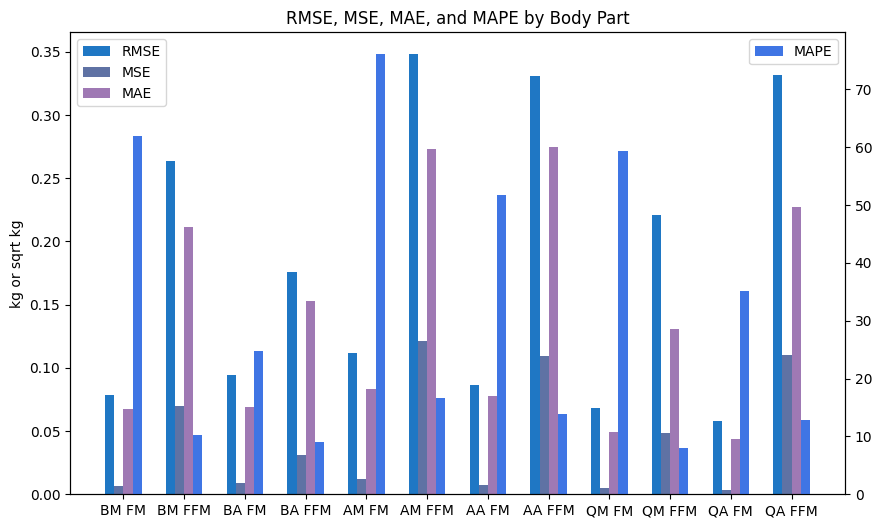

In [142]:
rmse_np = rmse.detach().cpu()
mse_np = mse.detach().cpu()
mae_np = mae.detach().cpu()
mape_np = mape.detach().cpu()

positions = torch.arange(len(body_parts))
width = 0.15  # the width of the bars

fig, ax1 = plt.subplots(figsize=(10, 6))
rects1 = ax1.bar(positions - 1.5*width, rmse_np.flatten(), width, label='RMSE',color ='#1f77c4')
rects2 = ax1.bar(positions - width/2, mse_np.flatten(), width, label='MSE',color = '#5f72a4')
rects3 = ax1.bar(positions + width/2, mae_np.flatten(), width, label='MAE',color = '#9f79b4')

ax2 = ax1.twinx()
rects4 = ax2.bar(positions + 1.5*width, mape_np.flatten(), width, label='MAPE', color='#3f75e4')

ax1.set_ylabel('kg or sqrt kg')
ax1.set_title('RMSE, MSE, MAE, and MAPE by Body Part')
ax1.set_xticks(positions)
ax1.set_xticklabels(body_parts)

ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

plt.xticks(rotation=45)
plt.show()